In [1]:
import json
import os
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.patches as mpatches
import arabic_reshaper
from bidi.algorithm import get_display

In [2]:
BASE_PATH = "../datasets/processed/question_answer_validated_label_studio/"
INPUT_FILES = [
    "qa_1_200_Atlas-Chat-9B_Atlas-Chat-2B_V2.json",
    "qa_1526_1747_gemini3Flash_Atlas-Chat-2B_V2.json",
    "qa_4576_4804_gemini3Flash_gemini3Flash_V2.json"
]
APPROACH_LABELS = [
    "Atlas-9B : Atlas-2B",
    "Gemini-Flash : Atlas-2B",
    "Gemini-Flash : Gemini-Flash"
]

QUESTION_FLAGS = ["Correct", "Grammar Error", "spelling error", "Ambiguous", "Incomplete"]
ANSWER_FLAGS   = ["Correct", "Wrong Answer", "Not in Context", "Incomplete", "Too Long"]

Q_COLORS = ["#2ecc71", "#e67e22", "#e74c3c", "#9b59b6", "#3498db"]
A_COLORS = ["#2ecc71", "#e74c3c", "#9b59b6", "#3498db", "#e67e22"]

In [3]:
datasets = []
for fname in INPUT_FILES:
    path = os.path.join(BASE_PATH, fname)
    with open(path, "r", encoding="utf-8") as f:
        datasets.append(json.load(f))

for label, data in zip(APPROACH_LABELS, datasets):
    print(f"{label} → {len(data)} examples")

Atlas-9B : Atlas-2B → 200 examples
Gemini-Flash : Atlas-2B → 200 examples
Gemini-Flash : Gemini-Flash → 200 examples


In [4]:
def draw_donut(ax, values, labels, colors, title):
    """Draw a donut chart with percentage labels on wedges."""
    total = sum(values)
    filtered = [(v, l, c) for v, l, c in zip(values, labels, colors) if v > 0]
    v_f, l_f, c_f = zip(*filtered) if filtered else ([], [], [])

    wedges, _ = ax.pie(
        v_f,
        colors=c_f,
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor="white", linewidth=1.5),
        pctdistance=0.75,
    )
    cumsum = 0
    import numpy as np
    for wedge, val in zip(wedges, v_f):
        pct = 100 * val / total
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = 0.72 * np.cos(np.radians(angle))
        y = 0.72 * np.sin(np.radians(angle))
        if pct >= 4:
            ax.text(x, y, f"{pct:.1f}%",
                   ha="center", va="center",
                   fontsize=8.5, fontweight="bold", color="white")
    ax.text(0, 0, f"n={total}",
           ha="center", va="center",
           fontsize=11, fontweight="bold", color="#444444")

    ax.set_title(title, fontsize=11, fontweight="bold", pad=12)
    legend_labels = [f"{l} ({v})" for l, v in zip(l_f, v_f)]
    patches = [mpatches.Patch(color=c, label=lbl)
               for c, lbl in zip(c_f, legend_labels)]
    ax.legend(handles=patches, loc="lower center",
              bbox_to_anchor=(0.5, -0.28),
              ncol=2, fontsize=8, frameon=False)

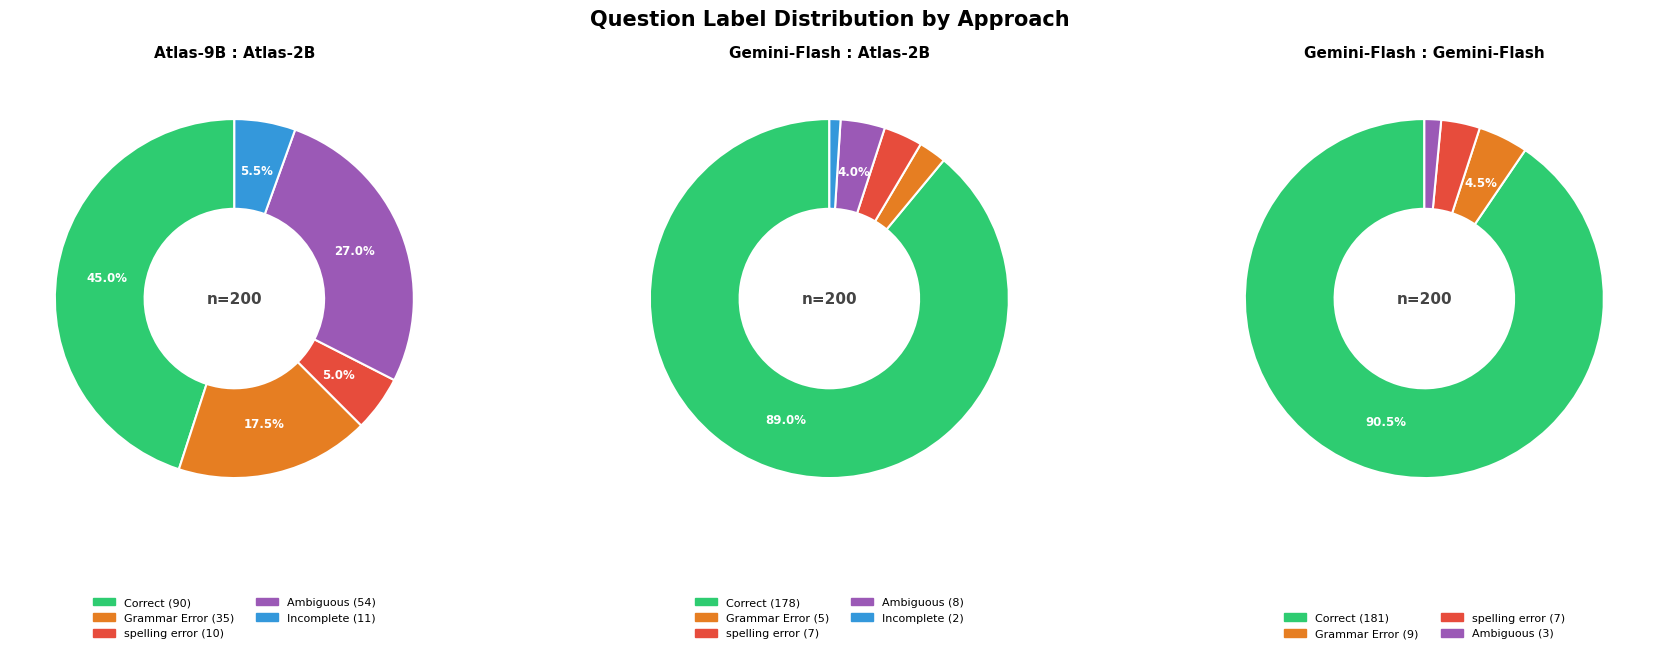

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Question Label Distribution by Approach",
             fontsize=15, fontweight="bold", y=1.02)

for i, (data, approach) in enumerate(zip(datasets, APPROACH_LABELS)):
    counts = Counter(d.get("question_label", "") for d in data)
    values = [counts.get(flag, 0) for flag in QUESTION_FLAGS]
    draw_donut(axes[i], values, QUESTION_FLAGS, Q_COLORS, approach)

plt.tight_layout()
plt.savefig("question_labels_donut.png", dpi=150, bbox_inches="tight")
plt.show()

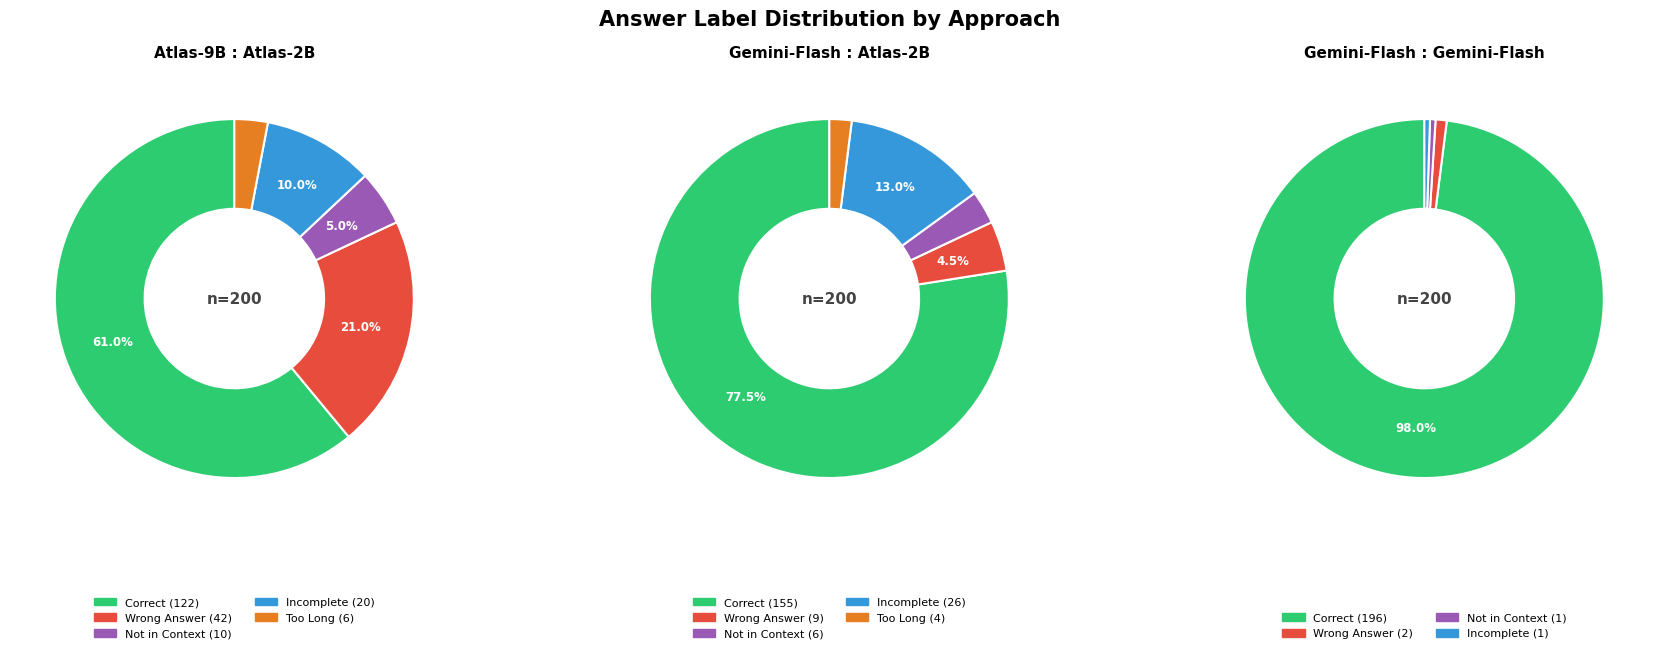

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Answer Label Distribution by Approach",
             fontsize=15, fontweight="bold", y=1.02)

for i, (data, approach) in enumerate(zip(datasets, APPROACH_LABELS)):
    counts = Counter(d.get("answer_label", "") for d in data)
    values = [counts.get(flag, 0) for flag in ANSWER_FLAGS]
    draw_donut(axes[i], values, ANSWER_FLAGS, A_COLORS, approach)

plt.tight_layout()
plt.savefig("answer_labels_donut.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
QUESTION_TYPES = ["شكون", "فين", "فوقاش", "شنو", "شحال", "معامن", "وقتاش"]

def get_question_type(question):
    """Return the first matching keyword found in the question, else 'other'."""
    for qtype in QUESTION_TYPES:
        if qtype in question:
            return qtype
    return "other"

In [8]:
results = {}

for data, approach in zip(datasets, APPROACH_LABELS):

    rows = []
    for d in data:
        qtype = get_question_type(d.get("question_corrected", d.get("question", "")))
        rows.append({
            "qtype"          : qtype,
            "question_error" : 0 if d.get("question_label") == "Correct" else 1,
            "answer_error"   : 0 if d.get("answer_label")   == "Correct" else 1,
        })

    df = pd.DataFrame(rows)

    # Keep only known question types, drop "other"
    df = df[df["qtype"].isin(QUESTION_TYPES)]

    stats = (
        df.groupby("qtype")[["question_error", "answer_error"]]
        .agg(
            q_error_rate=("question_error", "mean"),
            a_error_rate=("answer_error",   "mean"),
            count       =("question_error", "count")
        )
        .reindex(QUESTION_TYPES)   # keep fixed order
        .reset_index()
    )
    stats = stats[stats["count"] >= 10]
    results[approach] = stats

# Preview first approach
results[APPROACH_LABELS[0]]

,qtype,q_error_rate,a_error_rate,count
0,شكون,0.600000,0.285714,35
1,فين,0.571429,0.309524,42
2,فوقاش,0.400000,0.200000,20
3,شنو,0.517241,0.465517,58
4,شحال,0.466667,0.466667,30


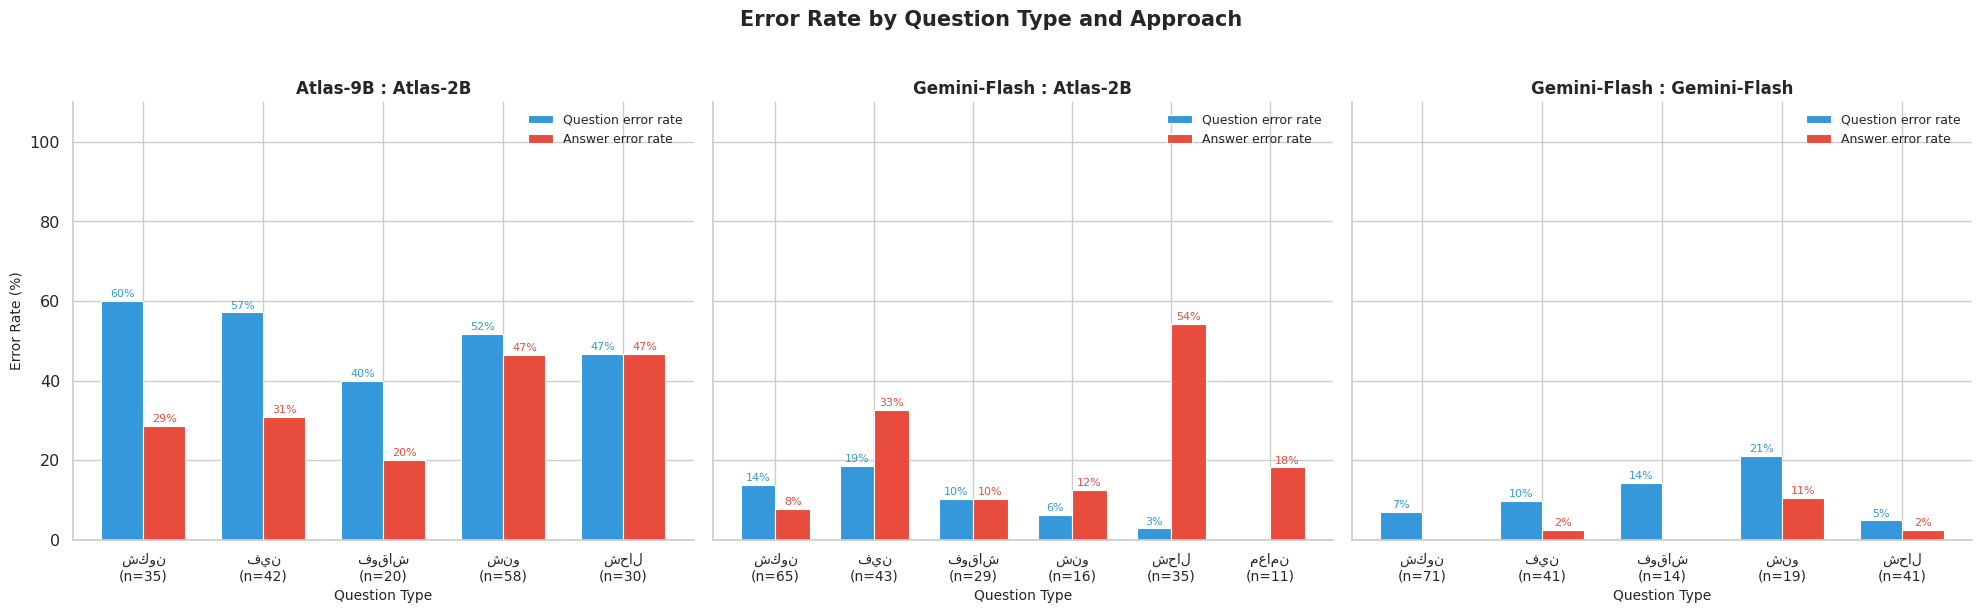

In [9]:
sns.set_theme(style="whitegrid", font_scale=1.05)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle("Error Rate by Question Type and Approach",
             fontsize=15, fontweight="bold", y=1.02)

BAR_W = 0.35
C_Q   = "#3498db"
C_A   = "#e74c3c"

for ax, approach in zip(axes, APPROACH_LABELS):
    stats   = results[approach]
    x       = np.arange(len(stats))

    q_rates = (stats["q_error_rate"] * 100).fillna(0).values
    a_rates = (stats["a_error_rate"] * 100).fillna(0).values
    counts  = stats["count"].fillna(0).astype(int).values

    bars_q = ax.bar(x - BAR_W/2, q_rates, BAR_W,
                    label="Question error rate", color=C_Q,
                    edgecolor="white", linewidth=0.8)
    bars_a = ax.bar(x + BAR_W/2, a_rates, BAR_W,
                    label="Answer error rate", color=C_A,
                    edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars_q, q_rates):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f"{val:.0f}%", ha="center", fontsize=8, color=C_Q)
    for bar, val in zip(bars_a, a_rates):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f"{val:.0f}%", ha="center", fontsize=8, color=C_A)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{qt}\n(n={c})" for qt, c in zip(stats["qtype"].values, counts)],
        fontsize=10
    )
    ax.set_title(approach, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 110)
    ax.set_xlabel("Question Type", fontsize=10)
    ax.set_ylabel("Error Rate (%)" if ax == axes[0] else "", fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("error_rate_by_question_type.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
dfs_q = []
for data, approach in zip(datasets, APPROACH_LABELS):
    df = pd.DataFrame(data)
    df["approach"]       = approach
    df["context_len"]    = df["context"].apply(lambda x: len(x.split()))
    df["question_error"] = (df["question_label"] != "Correct").astype(int)
    df["answer_error"]   = (df["answer_label"]   != "Correct").astype(int)

    # qcut = equal-frequency bins → each quartile has same n
    df["quartile"], bins = pd.qcut(
        df["context_len"],
        q=4,
        labels=["Q1\nShort", "Q2\nMed-Low", "Q3\nMed-High", "Q4\nLong"],
        retbins=True,
        duplicates="drop"
    )

    # Print bin edges so you know what "short" and "long" mean
    edges = [f"{b:.0f}" for b in bins]
    print(f"{approach} — quartile edges (words): {' | '.join(edges)}")

    dfs_q.append(df)

full_q = pd.concat(dfs_q, ignore_index=True)

Atlas-9B : Atlas-2B — quartile edges (words): 15 | 25 | 30 | 37 | 63
Gemini-Flash : Atlas-2B — quartile edges (words): 15 | 24 | 32 | 39 | 68
Gemini-Flash : Gemini-Flash — quartile edges (words): 15 | 26 | 31 | 38 | 65


In [11]:
grouped_q = (
    full_q
    .groupby(["approach", "quartile"], observed=True)
    [["question_error", "answer_error"]]
    .agg(
        q_error_rate=("question_error", "mean"),
        a_error_rate=("answer_error",   "mean"),
        count       =("question_error", "count")
    )
    .reset_index()
)

grouped_q["q_error_rate"] *= 100
grouped_q["a_error_rate"] *= 100

grouped_q

,approach,quartile,q_error_rate,a_error_rate,count
0,Atlas-9B : Atlas-2B,Q1\nShort,58.000000,32.000000,50
1,Atlas-9B : Atlas-2B,Q2\nMed-Low,57.407407,42.592593,54
2,Atlas-9B : Atlas-2B,Q3\nMed-High,47.916667,35.416667,48
3,Atlas-9B : Atlas-2B,Q4\nLong,56.250000,45.833333,48
4,Gemini-Flash : Atlas-2B,Q1\nShort,12.500000,14.285714,56
5,Gemini-Flash : Atlas-2B,Q2\nMed-Low,9.090909,18.181818,55
6,Gemini-Flash : Atlas-2B,Q3\nMed-High,9.302326,27.906977,43
7,Gemini-Flash : Atlas-2B,Q4\nLong,13.043478,32.608696,46
8,Gemini-Flash : Gemini-Flash,Q1\nShort,7.843137,3.921569,51
9,Gemini-Flash : Gemini-Flash,Q2\nMed-Low,12.500000,0.000000,56


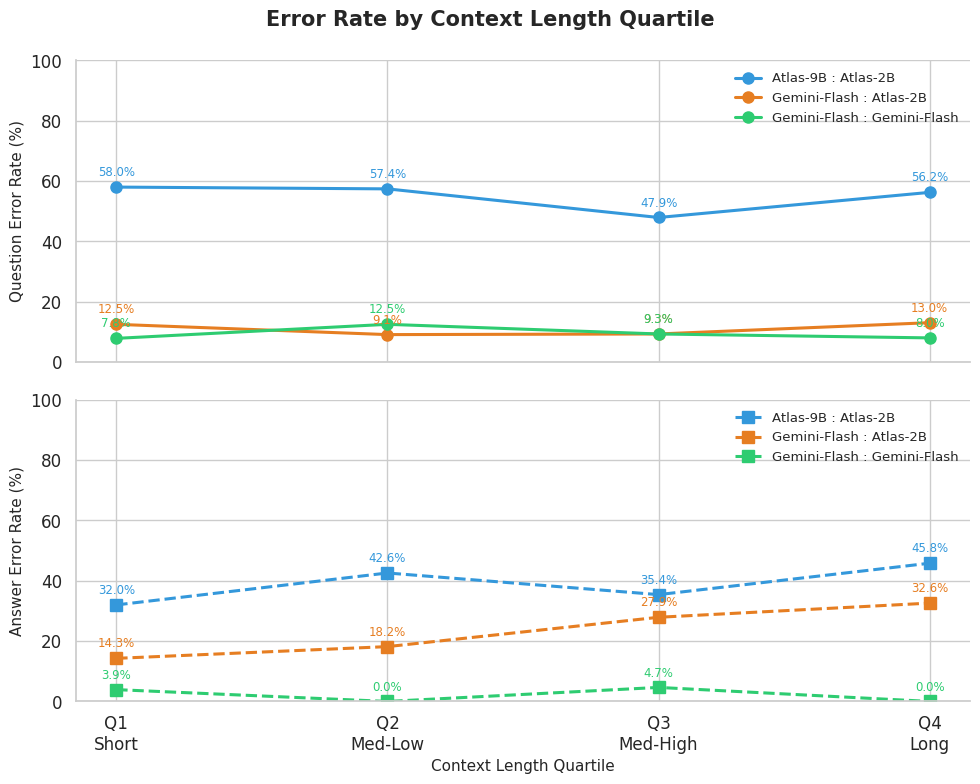

In [12]:
QUARTILE_LABELS = ["Q1\nShort", "Q2\nMed-Low", "Q3\nMed-High", "Q4\nLong"]
COLORS          = ["#3498db", "#e67e22", "#2ecc71"]

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Error Rate by Context Length Quartile",
             fontsize=15, fontweight="bold")

for approach, color in zip(APPROACH_LABELS, COLORS):
    sub = grouped_q[grouped_q["approach"] == approach]

    ax1.plot(sub["quartile"].astype(str), sub["q_error_rate"],
             marker="o", linewidth=2.2, markersize=8,
             label=approach, color=color)

    ax2.plot(sub["quartile"].astype(str), sub["a_error_rate"],
             marker="s", linewidth=2.2, markersize=8,
             label=approach, color=color, linestyle="--")

    # Annotate values on points
    for _, row in sub.iterrows():
        ax1.annotate(f"{row['q_error_rate']:.1f}%",
                     xy=(str(row["quartile"]), row["q_error_rate"]),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8.5, color=color)
        ax2.annotate(f"{row['a_error_rate']:.1f}%",
                     xy=(str(row["quartile"]), row["a_error_rate"]),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8.5, color=color)

for ax, title in zip([ax1, ax2], ["Question Error Rate (%)", "Answer Error Rate (%)"]):
    ax.set_ylabel(title, fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9.5, frameon=False)
    sns.despine(ax=ax)

ax2.set_xlabel("Context Length Quartile", fontsize=11)
plt.tight_layout()
plt.savefig("error_rate_by_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

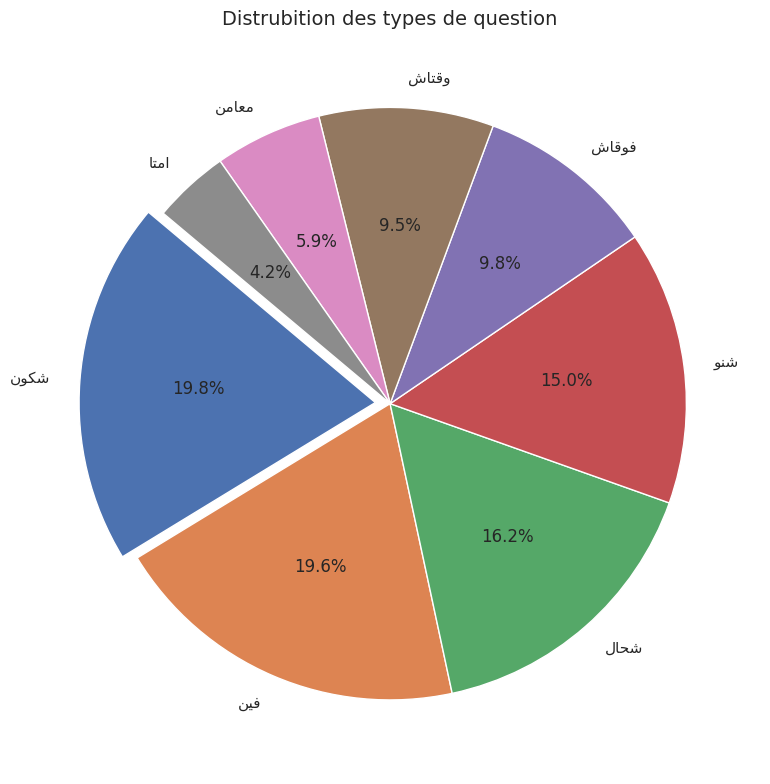

In [ ]:
DIR_PATH = "../datasets/processed/question_answer/"

total_examples = 0
question_types = Counter()

def extract_question_type(question):
    return question.strip().split()[0]

def reshape_arabic(text):
    return get_display(arabic_reshaper.reshape(text))

for file in os.listdir(DIR_PATH):
    if file.endswith(".json"):
        with open(os.path.join(DIR_PATH, file), "r", encoding="utf-8") as f:
            data = json.load(f)

            total_examples += len(data)

            for item in data:
                q = item["data"]["question"]
                q_type = extract_question_type(q)
                question_types[q_type] += 1

question_types = dict(sorted(question_types.items(), key=lambda x: x[1], reverse=True))

labels = list(question_types.keys())
sizes = list(question_types.values())

labels_ar = [reshape_arabic(label) for label in labels]

# explode (highlight biggest)
explode = [0.05 if i == 0 else 0 for i in range(len(labels))]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 8))

plt.pie(
    sizes,
    labels=labels_ar,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode
)

plt.title("Distrubition des types de question", fontsize=14)

plt.tight_layout()
plt.show()